## 1. Librerías

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
import math



## 2. Visualización del Dataset

In [27]:
df=pd.read_csv("Telco_Customer_Churn_Dataset.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 3. ETL

### Corrección tipos de datos

In [29]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

### Datos nulos y duplicados

In [30]:
print(f"Cantidad de datos ausentes: {df.isnull().sum().sum()}")
print(f"Cantidad de datos duplicados: {df.duplicated().sum()}")

Cantidad de datos ausentes: 11
Cantidad de datos duplicados: 0


In [31]:
df.drop_duplicates()
df = df.fillna(0)

In [32]:
print(f"Cantidad de datos ausentes: {df.isnull().sum().sum()}")
print(f"Cantidad de datos duplicados: {df.duplicated().sum()}")

Cantidad de datos ausentes: 0
Cantidad de datos duplicados: 0


### Transformación variable objetivo

In [33]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

### Separación de variables numéricas y categóricas

In [34]:
columnas_list= df.columns.tolist()
columnas_categoricas=df.select_dtypes(include=['object']).columns.tolist()
columnas_numericas= [col for col in columnas_list if col not in columnas_categoricas]

print(f"Columnas categóricas: {columnas_categoricas}")
print(f"Columnas numéricas: {columnas_numericas}")

Columnas categóricas: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Columnas numéricas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']


## 4. EDA

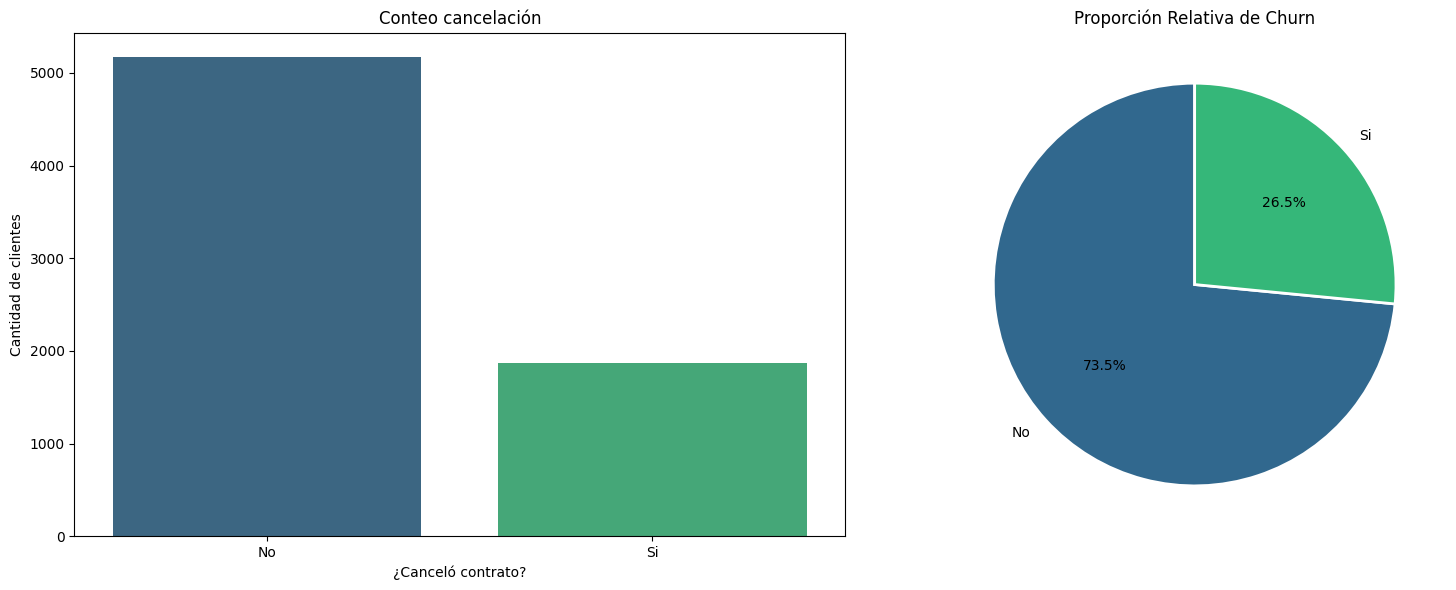

In [35]:
def plot_distribucion(df):


    churn_labels = df['Churn'].map({0: 'No', 1: 'Si'})

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 1. Gráfico de barras
    sns.countplot(
        data=df,
        x=churn_labels,
        order=['No', 'Si'],
        hue=churn_labels,
        palette='viridis',
        legend=False,
        ax=axes[0]
    )
    axes[0].set_title('Conteo cancelación')
    axes[0].set_xlabel('¿Canceló contrato?')
    axes[0].set_ylabel('Cantidad de clientes')
    axes[0].tick_params(axis='x', rotation=0)

    # 2. Gráfico de torta
    y_counts = churn_labels.value_counts()
    axes[1].pie(
        y_counts,
        labels=y_counts.index,
        autopct='%1.1f%%',
        colors=sns.color_palette('viridis', len(y_counts)),
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    axes[1].set_title('Proporción Relativa de Churn')

    plt.tight_layout()
    plt.show()

plot_distribucion(df)

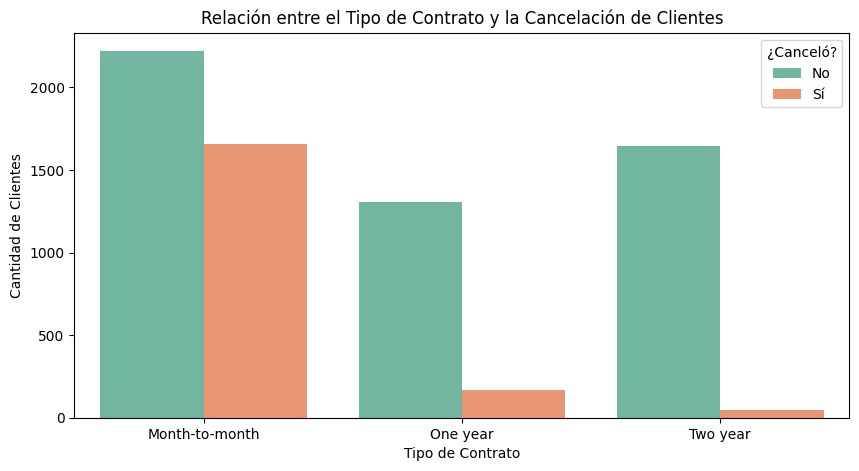

In [36]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Contract', hue=df['Churn'].map({0: 'No', 1: 'Sí'}), palette='Set2')
plt.title('Relación entre el Tipo de Contrato y la Cancelación de Clientes')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Cantidad de Clientes')
plt.legend(title='¿Canceló?')
plt.show()

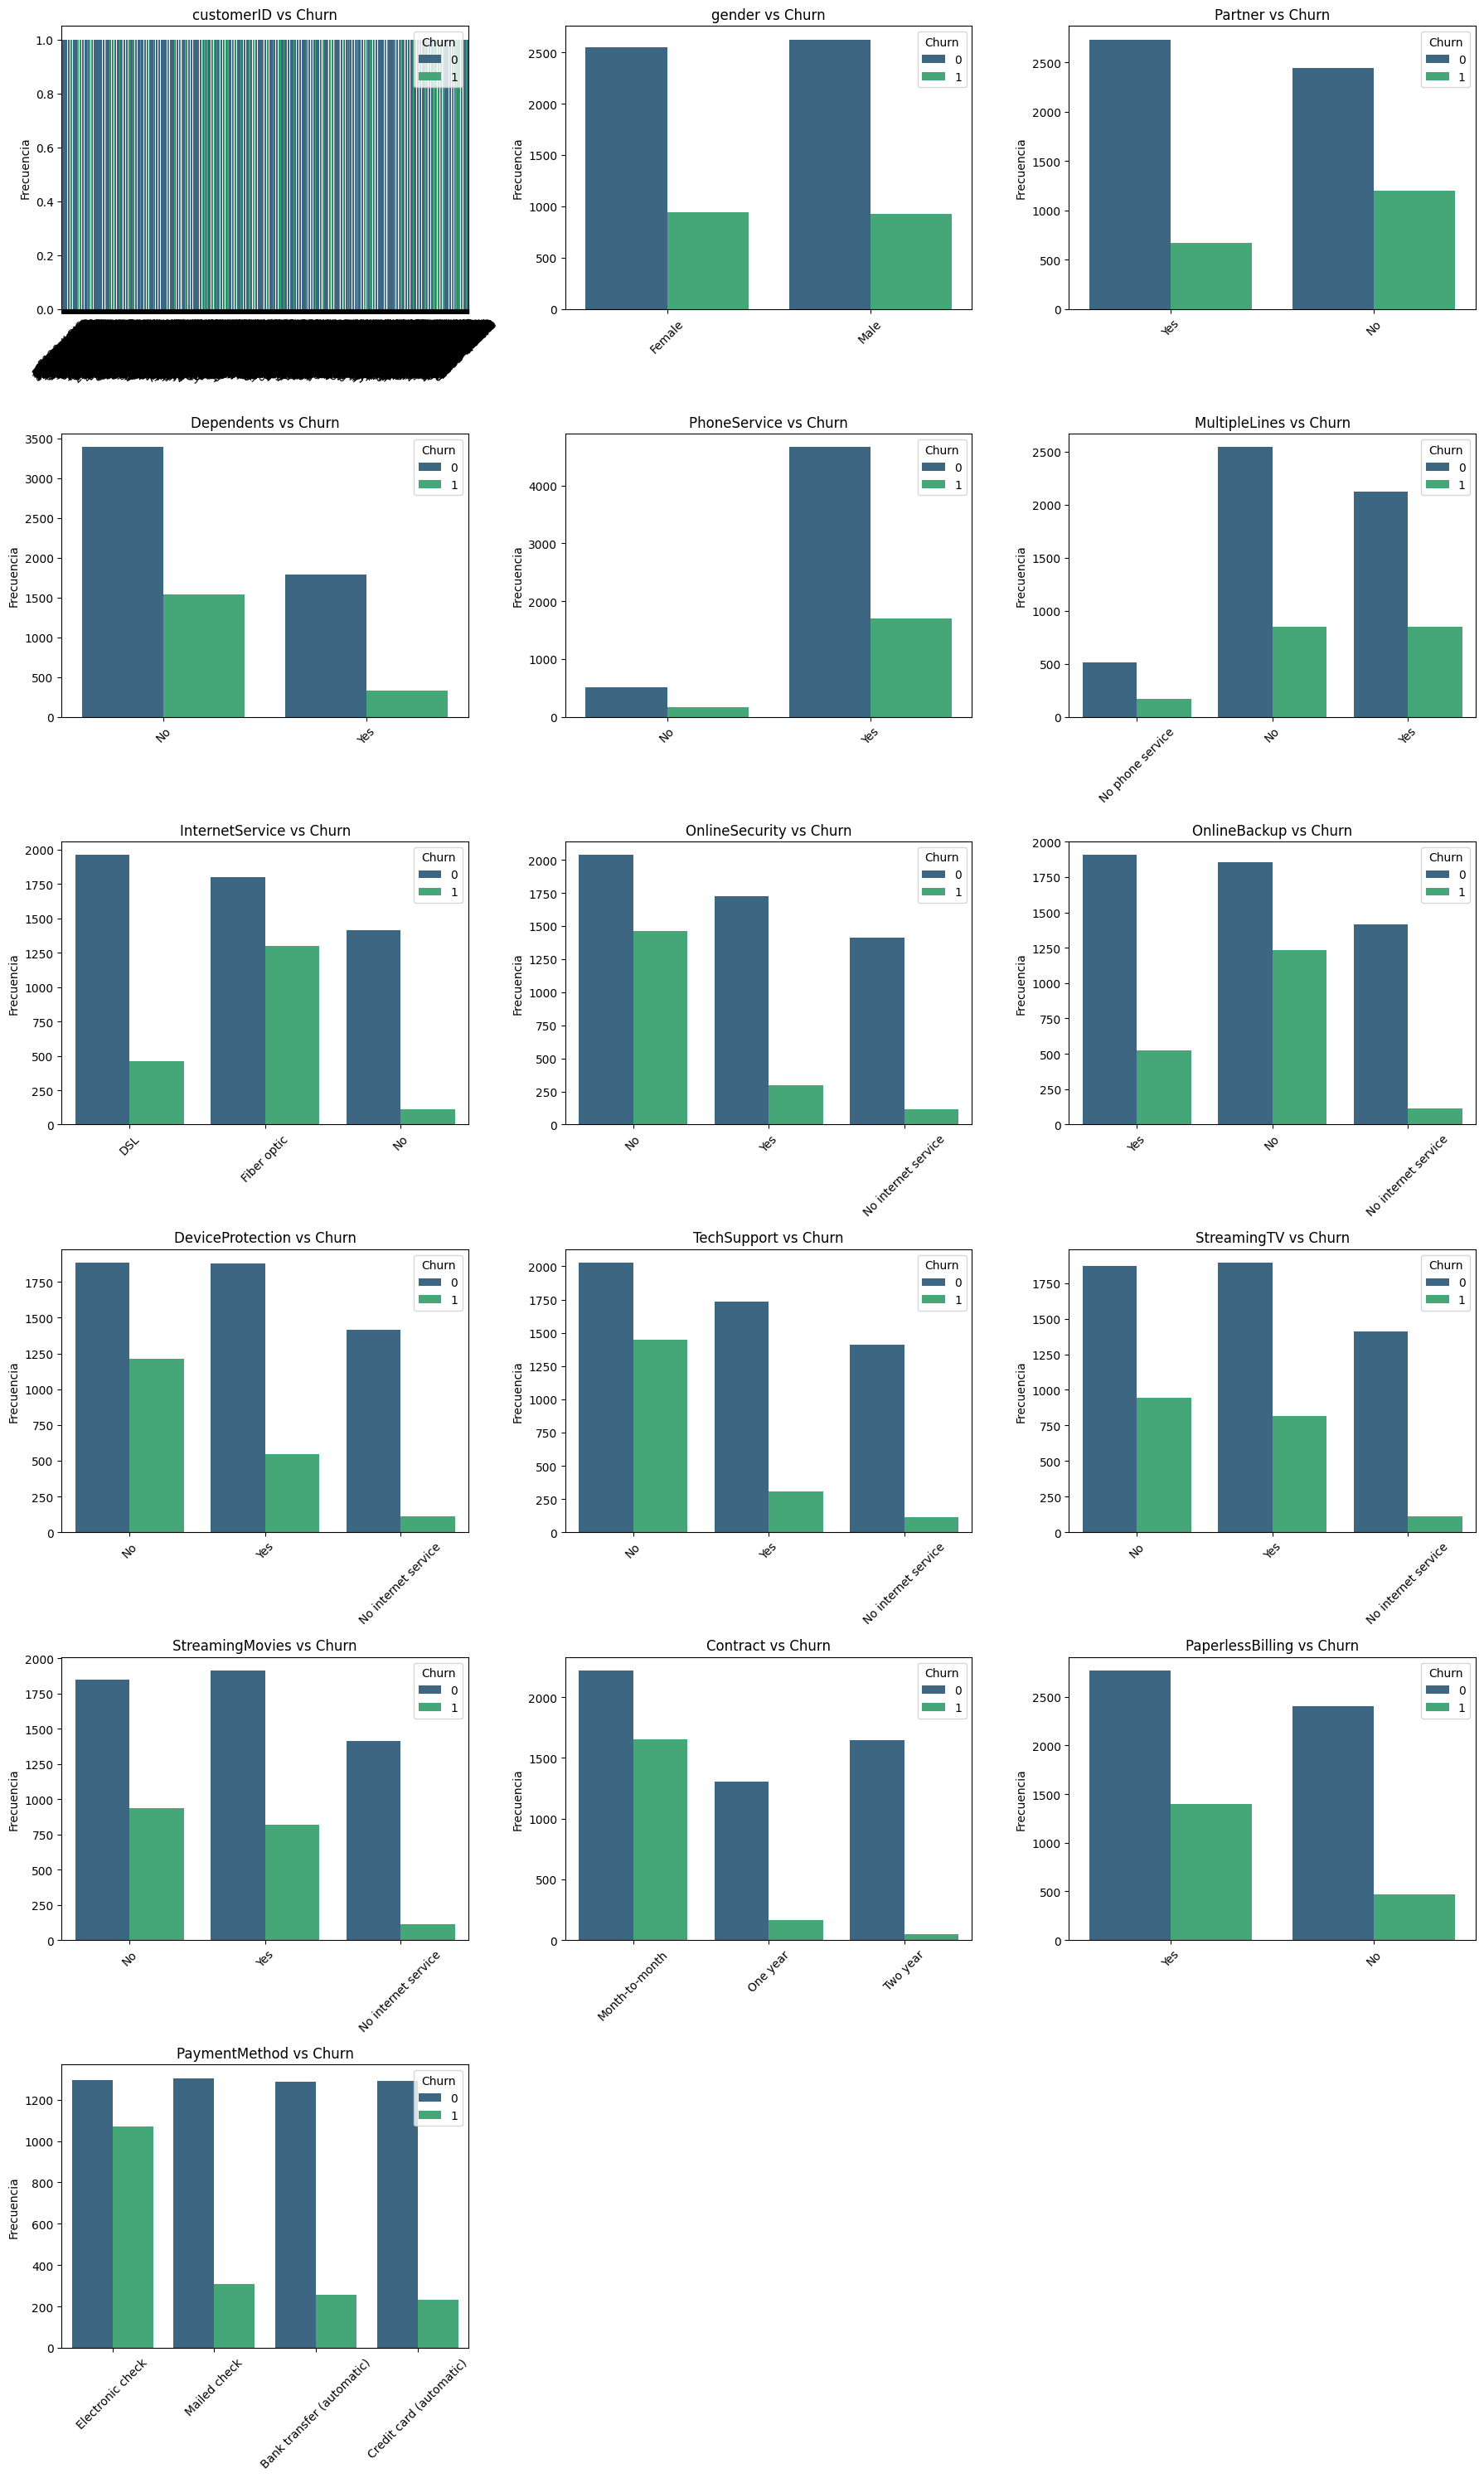

In [37]:
def plot_categorical(df_pred, columnas_grid=3):

    cat_cols = df_pred.select_dtypes(
        include=['object', 'category']
    ).columns.tolist()


    if 'Churn' in cat_cols:
        cat_cols.remove('Churn')

    if not cat_cols:
        print("No categorical columns to plot.")
        return

    filas_grid = math.ceil(
        len(cat_cols) / columnas_grid
    )

    fig, axes = plt.subplots(
        filas_grid,
        columnas_grid,
        figsize=(18, 5 * filas_grid)
    )

    axes = axes.flatten()

    for i, col in enumerate(cat_cols):

        sns.countplot(
            data=df_pred,
            x=col,
            hue='Churn',
            palette='viridis',
            ax=axes[i]
        )

        axes[i].set_title(f'{col} vs Churn')

        axes[i].tick_params(
            axis='x',
            rotation=45
        )

        axes[i].set_xlabel('')

        axes[i].set_ylabel('Frecuencia')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()

    plt.show()

plot_categorical(df)

## 5. Preprocesamiento y Codificación para Machine Learning

In [38]:
#Se elimina customerID ya que no aporta valor predictivo
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# One-Hot para las variables categóricas
df_model = pd.get_dummies(df, drop_first=True)

#Separar variables independientes (X) y variable objetivo (y)
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

#División de datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensiones de entrenamiento: {X_train.shape}")
print(f"Dimensiones de prueba: {X_test.shape}")

Dimensiones de entrenamiento: (5634, 30)
Dimensiones de prueba: (1409, 30)


## Modelamiento y Evaluación Inicial (Baseline con Regresión Logística)

In [39]:
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train, y_train)

# Predicciones
y_pred = modelo_lr.predict(X_test)

# Evaluación

print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


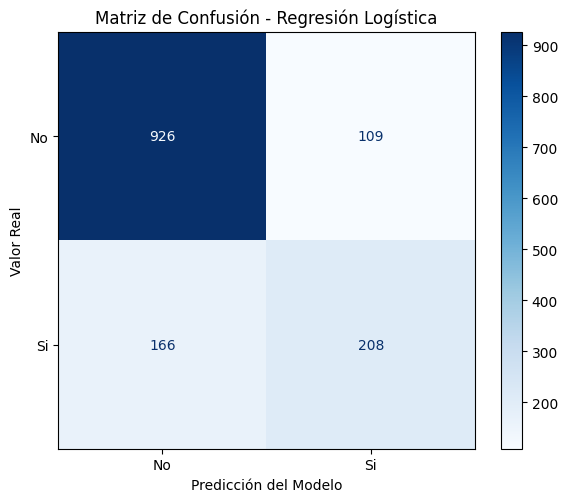

In [40]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Si'])

disp.plot(cmap=plt.cm.Blues, values_format='d', ax=plt.axes())

plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.grid(False)
plt.tight_layout()
plt.show()

## RandomForest

--- Resultados Random Forest ---
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.50      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



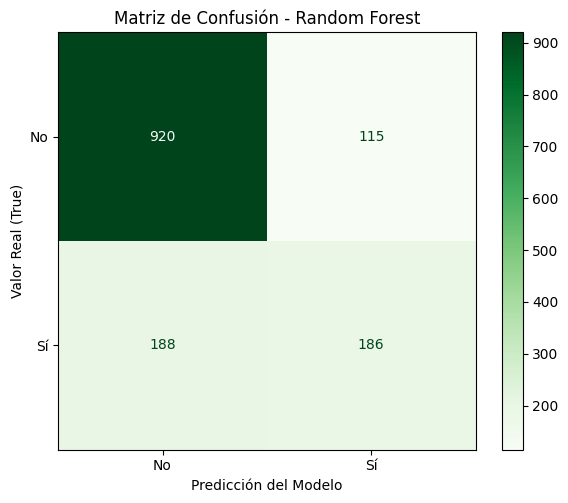

In [41]:
modelo_rf = RandomForestClassifier(random_state=42, n_estimators=100)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

print("--- Resultados Random Forest ---")

print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred_rf))


plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_rf), display_labels=['No', 'Sí'])
disp.plot(cmap=plt.cm.Greens, values_format='d', ax=plt.axes())
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real (True)')
plt.grid(False)
plt.tight_layout()
plt.show()